In [ ]:
import os
import sys
import pandas as pd
import argparse
import warnings
from utils import *
from torch import nn
import copy
from tqdm import tqdm
import random 
from data_loader import *
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import numpy as np
from http import HTTPStatus
import dashscope
from xgboost import XGBRegressor
from dashscope import Generation
import json
# import openai
from deepseek import DeepSeekClient
import os
from train import *
from model import GurobiPowerScheduler_milp
import pickle
from together import Together
from openai import OpenAI
warnings.filterwarnings("ignore")
#set deepseek and openai API keys



dashscope.api_key = 'your key'
DEEPSEEK_API_KEY =  'your key'
OPENAI_API_KEY =  'your key'
LLAMA_API_KEY= 'your key'

In [2]:
parser_train = argparse.ArgumentParser()
parser_train.add_argument('--seq_len', type=int, default=24*7)
parser_train.add_argument('--pred_len', type=int, default=24)
parser_train.add_argument('--label_len', type=int, default=0)
parser_train.add_argument('--train_length', type=int, default=17376)
parser_train.add_argument('--target', type=str, default='target')
parser_train.add_argument('--scale', type=bool, default=True)
parser_train.add_argument('--inverse', type=bool, default=True)
parser_train.add_argument('--num_epochs', type=int, default=1000)
parser_train.add_argument('--mode', type=str, default='seq2seq')
parser_train.add_argument('--quantiles', type=list, default=[0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95])
parser_train.add_argument('--lr', type=float, default=1e-3)
parser_train.add_argument('--patience', type=int, default=5)
parser_train.add_argument('--hidden_layers', type=list, default=[128,128,128])
parser_train.add_argument('--e2e_num_epochs', type=int, default=5)
parser_train.add_argument('--e2e_ft_lr', type=float, default=1e-6)
parser_train.add_argument('--e2e_lr', type=float, default=1e-7)#1e-7
parser_train.add_argument('--ft_lr', type=float, default=1e-4)
parser_train.add_argument('--batch_size', type=int, default=16)
parser_train.add_argument('--device', type=str, default='cuda:0' if torch.cuda.is_available() else 'cpu')
parser_train.add_argument('--epsion_p', type=float, default=1e1)
parser_train.add_argument('--epsion_l', type=float, default=1e1)
parser_train.add_argument('--metric_list', type=list, default=['pinball_loss','winkler_score_0.1','MAE','RMSE'])


parser_train.add_argument('--N_g', type=int, default=3)
parser_train.add_argument('--T', type=int, default=24)
parser_train.add_argument('--N', type=int, default=25)
parser_train.add_argument('--x_max', type=int, default=[1500,1800,2000])
parser_train.add_argument('--x_min', type=int, default=[200,300,400])
parser_train.add_argument('--z_pos_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_neg_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_pos_min', type=int, default=0)
parser_train.add_argument('--z_neg_min', type=int, default=0)
parser_train.add_argument('--r_neg', type=int, default=[800,800,500])
parser_train.add_argument('--r_pos', type=int, default=[800,800,500])
parser_train.add_argument('--alpha', type=list, default=[0.03 for i in range(24)]+[0.028 for i in range(24)]+[0.032 for i in range(24)])
parser_train.add_argument('--alpha_pos', type=list, default=[0.02 for i in range(24)]+[0.018 for i in range(24)]+[0.022 for i in range(24)])
parser_train.add_argument('--alpha_neg', type=list, default=[0.01 for i in range(24)]+[0.009 for i in range(24)]+[0.011 for i in range(24)])

parser_train.add_argument('--rho_z_pos', type=list, default=[0.05 for i in range(24)]+[0.045 for i in range(24)]+[0.055 for i in range(24)])
parser_train.add_argument('--rho_z_neg', type=list, default=[0.01 for i in range(24)]+[0.008 for i in range(24)]+[0.012 for i in range(24)])

parser_train.add_argument('--rho_r_pos', type=list, default=[0.1 for i in range(24)])
parser_train.add_argument('--rho_r_neg', type=list, default=[0.05 for i in range(24)])
parser_train.add_argument('--min_up_time', type=int, default=6)
parser_train.add_argument('--price_ratio_large', type=float, default=2.5)
parser_train.add_argument('--price_ratio_small', type=float, default=0.8)
parser_train.add_argument('--flag_dynamic_price', type=bool, default=False)
parser_train.add_argument('--flag_dynamic_mode', type=int, default=2)
parser_train.add_argument('--upper_quantiles', type=float, default=0.95)
parser_train.add_argument('--lower_quantiles', type=float, default=0.05)
parser_train.add_argument('--epsion', type=float, default=1)
parser_train.add_argument('--LLM_type', type=str, default='Qwen')
args = parser_train.parse_args(args=[])

In [3]:
train_load_data,train_load_loader=get_load_data(args,flag='train')
val_load_data,val_load_loader=get_load_data(args,flag='val')
test_load_data,test_load_loader=get_load_data(args,flag='test')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

X_test=train_load_data.inverse_transform_X(test_load_data.X)
X_train=train_load_data.inverse_transform_X(train_load_data.X)
X_val=train_load_data.inverse_transform_X(val_load_data.X)

../../Data/GEF_data/data(3 year).csv
(26113, 219)
../../Data/GEF_data/data(3 year).csv
(26113, 219)
../../Data/GEF_data/data(3 year).csv
(26113, 219)


In [4]:
from utils import *
combined_train_data,combined_train_loader,combined_val_data,combined_val_loader,combined_test_data,combined_test_loader,combined_fine_tune_data,combined_fine_tune_loader = obtain_price(args,train_load_data,val_load_data,test_load_data)
data_iter = iter(combined_test_loader)
input_load_test, labels_load_test, alpha_test, alpha_z_test, rho_z_test, rho_r_test = next(data_iter)

alpha_sample=alpha_test[0,:].detach().cpu().numpy()
alpha_z_sample=alpha_z_test[0,:].detach().cpu().numpy()
rho_z_sample=rho_z_test[0,:].detach().cpu().numpy()
rho_r_sample=rho_r_test[0,:].detach().cpu().numpy()

optimization_module = GurobiPowerScheduler_milp(args, alpha_sample, alpha_z_sample, rho_z_sample, rho_r_sample)

Test data is not shuffled
Test data is not shuffled
[1500. 1800. 2000.]
[200. 300. 400.]


In [5]:
input_size=train_load_data.X.shape[-1]
output_size=24
set_seed(42)

layer_sizes=[128,128,128]
model_load=ANN(input_size=input_size, layer_sizes=layer_sizes, output_size=output_size).to(device)
train(args, model_load, train_load_loader, val_load_loader,dir_best_model='../Model/best_ann_load.pt')

Using device: cuda:0
Epoch [1/1000] Train Loss: 0.0588 Val Loss: 0.0193
Epoch [2/1000] Train Loss: 0.0090 Val Loss: 0.0075
Epoch [3/1000] Train Loss: 0.0059 Val Loss: 0.0069
Epoch [4/1000] Train Loss: 0.0054 Val Loss: 0.0066
Epoch [5/1000] Train Loss: 0.0053 Val Loss: 0.0064
Epoch [6/1000] Train Loss: 0.0049 Val Loss: 0.0060
Epoch [7/1000] Train Loss: 0.0049 Val Loss: 0.0057
Epoch [8/1000] Train Loss: 0.0052 Val Loss: 0.0055
Epoch [9/1000] Train Loss: 0.0043 Val Loss: 0.0052
Epoch [10/1000] Train Loss: 0.0041 Val Loss: 0.0048
Epoch [11/1000] Train Loss: 0.0038 Val Loss: 0.0046
Epoch [12/1000] Train Loss: 0.0037 Val Loss: 0.0043
Epoch [13/1000] Train Loss: 0.0034 Val Loss: 0.0041
Epoch [14/1000] Train Loss: 0.0036 Val Loss: 0.0038
Epoch [15/1000] Train Loss: 0.0034 Val Loss: 0.0036
Epoch [16/1000] Train Loss: 0.0028 Val Loss: 0.0038
Epoch [17/1000] Train Loss: 0.0029 Val Loss: 0.0035
Epoch [18/1000] Train Loss: 0.0029 Val Loss: 0.0032
Epoch [19/1000] Train Loss: 0.0026 Val Loss: 0.0029


In [6]:
cost_calculation=False
if 'cost_lists_milp.pkl' not in os.listdir():
    cost_calculation=True
else:
    with open('cost_lists_milp.pkl', 'rb') as f:
        cost_result=pickle.load(f)
        cost_list_train=cost_result['cost_list_train']
        cost_list_train_ideal=cost_result['cost_list_train_ideal']
        cost_list_val=cost_result['cost_list_val']
        cost_list_val_ideal=cost_result['cost_list_val_ideal']
        cost_list_test=cost_result['cost_list_test']
        cost_list_ideal=cost_result['cost_list_test_ideal']

In [7]:
test_input=torch.tensor(test_load_data.X).to(device).float()
test_pred_nor=model_load(test_input).detach().cpu().numpy()
test_pred = train_load_data.inverse_transform(test_pred_nor)
test_actual_nor=test_load_data.y
test_actual = train_load_data.inverse_transform(test_actual_nor)

print(MAE(test_pred,test_actual),RMSE(test_pred,test_actual),MAPE(test_pred,test_actual))

if cost_calculation:
    cost_list_test=[]
    cost_list_ideal=[]
    for i in range(len(test_pred)):
        forecasts=test_pred[i,:]
        actual=test_actual[i,:]
        _,_,costs_org=optimization_module.forward(forecasts,actual)
        _,_,costs_ideal=optimization_module.forward(actual,actual)
        cost_list_test.append(costs_org)
        cost_list_ideal.append(costs_ideal)


val_input=torch.tensor(val_load_data.X).to(device).float()
val_pred_nor=model_load(val_input).detach().cpu().numpy()
val_pred = train_load_data.inverse_transform(val_pred_nor)
val_actual_nor=val_load_data.y#.reshape(-1,1)
val_actual = train_load_data.inverse_transform(val_actual_nor)

print(MAE(val_pred,val_actual),RMSE(val_pred,val_actual),MAPE(val_pred,val_actual))

if cost_calculation:
    cost_list_val_ideal=[]
    cost_list_val=[]
    for i in range(len(val_pred)):
        forecasts=val_pred[i,:]
        actual=val_actual[i,:]
        _,_,costs_org=optimization_module.forward(forecasts,actual)
        _,_,costs_ideal=optimization_module.forward(actual,actual)
        cost_list_val.append(costs_org)
        cost_list_val_ideal.append(costs_ideal)

train_input=torch.tensor(train_load_data.X).to(device).float()
train_pred_nor=model_load(train_input).detach().cpu().numpy()
train_pred = train_load_data.inverse_transform(train_pred_nor)
train_actual_nor=train_load_data.y#.reshape(-1,1)
train_actual = train_load_data.inverse_transform(train_actual_nor)
print(MAE(train_pred,train_actual),RMSE(train_pred,train_actual),MAPE(train_pred,train_actual))
if cost_calculation:
    cost_list_train_ideal=[]
    cost_list_train=[]
    for i in range(len(train_pred)):
        forecasts=train_pred[i,:]
        actual=train_actual[i,:]
        _,_,costs_org=optimization_module.forward(forecasts,actual)
        _,_,costs_ideal=optimization_module.forward(actual,actual)
        cost_list_train.append(costs_org)
        cost_list_train_ideal.append(costs_ideal)
    #save cost_list_train，cost_list_train_ideal，cost_list_val，cost_list_val_ideal，cost_list_test，cost_list_test_ideal into a pkl

108.93030977797234 139.44284533957995 0.029723884245756324
93.48481050557758 131.1995755421263 0.027242015189285804
86.26146852859128 118.6684663545049 0.025493223048933752


In [8]:
from E2E import E2E_test_ideal,E2E_test,E2E_train

In [9]:
from model import *
from E2E import *

In [10]:
cost_list_test_insert=[cost_list_test[i]-cost_list_ideal[i] for i in range(len(cost_list_test))]
actual_load_test_insert=test_actual_nor
forecasts_load_test_insert=test_pred_nor

cost_list_train_insert=[cost_list_train[i]-cost_list_train_ideal[i] for i in range(len(cost_list_train))]
actual_load_train_insert=train_actual_nor
forecasts_load_train_insert=train_pred_nor

cost_list_val_insert=[cost_list_val[i]-cost_list_val_ideal[i] for i in range(len(cost_list_val))]
actual_load_val_insert=val_actual_nor
forecasts_load_val_insert=val_pred_nor

db_train = CurveDictDB()
cur_id_start = max(db_train.data.keys(), default=0) + 1
for i, (cost, load, fine_tuned_load, actual_load) in enumerate(zip(cost_list_train_insert, forecasts_load_train_insert,forecasts_load_train_insert, actual_load_train_insert)):
    record = {
        'id': cur_id_start + i,
        'flag': 0,
        'prompt': '',
        'load': load,
        'fine_tuned_load': fine_tuned_load,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0, # 1代表成本比fine tune前低
    }
    db_train.insert(record)

db_val = CurveDictDB()
cur_id_start_val = max(db_val.data.keys(), default=0) + 1
for i, (cost, load, fine_tuned_load, actual_load) in enumerate(zip(cost_list_val_insert, forecasts_load_val_insert, forecasts_load_val_insert, actual_load_val_insert)):
    record = {
        'id': cur_id_start_val + i,
        'flag': 0,
        'prompt': '',
        'load': load,
        'fine_tuned_load': fine_tuned_load,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0,
    }
    db_val.insert(record)


In [11]:
prop_list=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
result={}
for prop in prop_list:
    result[prop]={}
    result[prop]['fine_tuned_load']=[]
    result[prop]['fine_tuned_cost']=[]
    result[prop]['org_cost']=[]
    result[prop]['org_load']=[]
    for inqure_id in range(len(forecasts_load_test_insert)):
        print(f"Processing inquiry {inqure_id+1}/{len(forecasts_load_test_insert)}")
        data_for_inqure = {
            'load': forecasts_load_test_insert[inqure_id],
           # 'fine_tuned_load': forecasts_load_test_insert_optnet[inqure_id],
        }

        actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(actual_load_test_insert[inqure_id]).reshape(1,-1))[0]

        similar_days = db_train.get_top_k_unique_loads(data_for_inqure['load'], k=3, q=1)[0:3]
        average_similar_load_org = np.mean([day['load'] for day in similar_days], axis=0)
        average_similar_load_actual = np.mean([day['actual_load'] for day in similar_days], axis=0)
        average_similar_load_optnet = np.mean([day['fine_tuned_load'] for day in similar_days], axis=0)
        average_similar_load_org_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_org).reshape(1,-1))[0]
        average_similar_load_actual_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_actual).reshape(1,-1))[0]
        _, _, obj_org_similar_days = optimization_module.forward(average_similar_load_org_numpy, average_similar_load_actual_numpy)
        obj_org_similar_days = obj_org_similar_days.item()

        # average_similar_load_optnet_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_optnet).reshape(1,-1))[0]
        # _, _, obj_optnet_similar_days = optimization_module.forward(average_similar_load_optnet_numpy, average_similar_load_actual_numpy)
        # obj_optnet_similar_days = obj_optnet_similar_days.item()

        print('Similar days original cost:', obj_org_similar_days)#'Similar days optnet cost:', obj_optnet_similar_days)
        load_nor = data_for_inqure['load']
        average_similar_load = average_similar_load_optnet
        load_numpy_org = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['load']).reshape(1,-1))[0]

        errors = average_similar_load_org - average_similar_load_actual
        
        selected_curve = data_for_inqure['load'] - errors * prop
        fine_tuned_load_numpy =  train_load_data.scaler_y.inverse_transform(np.array(selected_curve).reshape(1, -1))[0]
        _, _, obj_org = optimization_module.forward(load_numpy_org, actual_load_numpy)
        _, _, obj_fine_tune = optimization_module.forward(fine_tuned_load_numpy, actual_load_numpy)

        result[prop]['fine_tuned_cost'].append(obj_fine_tune)
        result[prop]['fine_tuned_load'].append(fine_tuned_load_numpy)
        print
        result[prop]['org_cost'].append(obj_org)
        result[prop]['org_load'].append(data_for_inqure['load'])

Processing inquiry 1/29
Set parameter Username
Academic license - for non-commercial use only - expires 2026-08-26


Similar days original cost: 2438.8640909830733
Processing inquiry 2/29
Similar days original cost: 2500.0545942382814
Processing inquiry 3/29
Similar days original cost: 2571.2651528320307
Processing inquiry 4/29
Similar days original cost: 2574.4462592773434
Processing inquiry 5/29
Similar days original cost: 2601.5883701171874
Processing inquiry 6/29
Similar days original cost: 2390.9738647460936
Processing inquiry 7/29
Similar days original cost: 2413.621889811198
Processing inquiry 8/29
Similar days original cost: 2581.1505330403643
Processing inquiry 9/29
Similar days original cost: 2721.180604654948
Processing inquiry 10/29
Similar days original cost: 2751.0201137695317
Processing inquiry 11/29
Similar days original cost: 2721.180586100261
Processing inquiry 12/29
Similar days original cost: 2816.95509358724
Processing inquiry 13/29
Similar days original cost: 2816.95509358724
Processing inquiry 14/29
Similar days original cost: 2746.9800249023438
Processing inquiry 15/29
Similar

In [12]:
fine_tuned_cost_lst=[]
for prop in prop_list:
    fine_tuned_cost_lst.append(np.mean(result[prop]['fine_tuned_cost']))

In [3]:
import pandas as pd

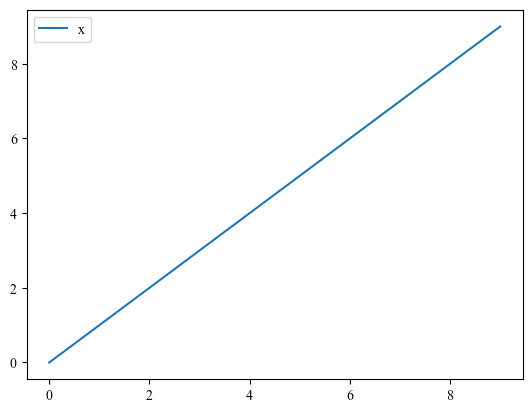

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
from matplotlib import font_manager as fm

font_path = '../../times.ttf' # 或绝对路径 '/home/me/fonts/times.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

mpl.rcParams['font.family'] = font_name
plt.plot(range(10),range(10),label='x')
plt.legend()

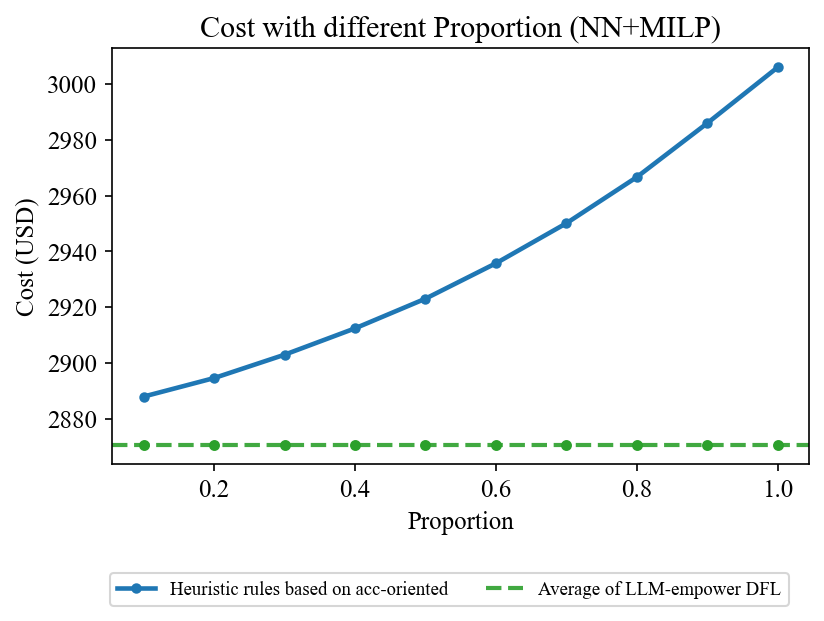

In [13]:
plt.rcParams['font.size'] = 12   
x = np.asarray(prop_list, dtype=float)
y_ft = np.asarray(fine_tuned_cost_lst, dtype=float)

ds, qwen, llama = 2866.62, 2869.88, 2875.05
baseline_avg = (ds + qwen + llama) / 3.0

fig, ax = plt.subplots(figsize=(6, 4.2), dpi=150)

ax.plot(x, y_ft, lw=2.2, marker="o", ms=4, color="#1f77b4", label="Heuristic rules based on acc-oriented")
ax.axhline(baseline_avg, ls="--", lw=2.0, color="#2ca02c", alpha=0.9,
           label=f"Average of LLM-empower DFL")

# 如果你想在水平线上也显示一些点，用 scatter（可选）
k = max(1, len(x)//8)
xm = x[::k]
ax.scatter(xm, np.full_like(xm, baseline_avg), s=18, color="#2ca02c", zorder=3)

ax.set_xlabel("Proportion")
ax.set_ylabel("Cost (USD)")
ax.set_title("Cost with different Proportion (NN+MILP)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=True, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.22)
plt.savefig('../../Figure/Heuristic_NN_MILP.jpg',dpi=1000)
plt.show()